In [129]:
# !pip install -q numpy scikit-learn pandas matplotlib seaborn 

Week 01 (2026/08/18)

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# You can define your own functions here
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [131]:
# Open the dataset
data = pd.read_csv('auto-mpg.csv')
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [132]:
# Understand the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB


In [133]:
# Clean the dataset
df_clean = (
    data.drop(columns=['origin', 'car name']) # Drop non-numeric columns
    .dropna() # Drop row with missing values
    .reset_index(drop=True) # Reset index after dropping rows
)
df_clean.head(10);

In [134]:
df_clean.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70
5,15.0,8,429.0,198,4341,10.0,70
6,14.0,8,454.0,220,4354,9.0,70
7,14.0,8,440.0,215,4312,8.5,70
8,14.0,8,455.0,225,4425,10.0,70
9,15.0,8,390.0,190,3850,8.5,70


In [135]:
df_clean.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [136]:
# Get all column names
df_clean.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year'],
      dtype='str')

In [137]:
df_clean.columns.to_list()

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year']

In [138]:
TARGET = 'mpg'
quan_candidates = ['displacement', 'horsepower', 'weight', 'acceleration', 'model year']


In [139]:
df_clean[TARGET]

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [140]:
df_clean[quan_candidates]

,displacement,horsepower,weight,acceleration,model year
0,307.0,130,3504,12.0,70
1,350.0,165,3693,11.5,70
2,318.0,150,3436,11.0,70
3,304.0,150,3433,12.0,70
4,302.0,140,3449,10.5,70
...,...,...,...,...,...
393,140.0,86,2790,15.6,82
394,97.0,52,2130,24.6,82
395,135.0,84,2295,11.6,82
396,120.0,79,2625,18.6,82


Week 02 (2026/09/01)

In [141]:
df_clean.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [142]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


In [143]:
cols = [TARGET] + quan_candidates
cols

['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']

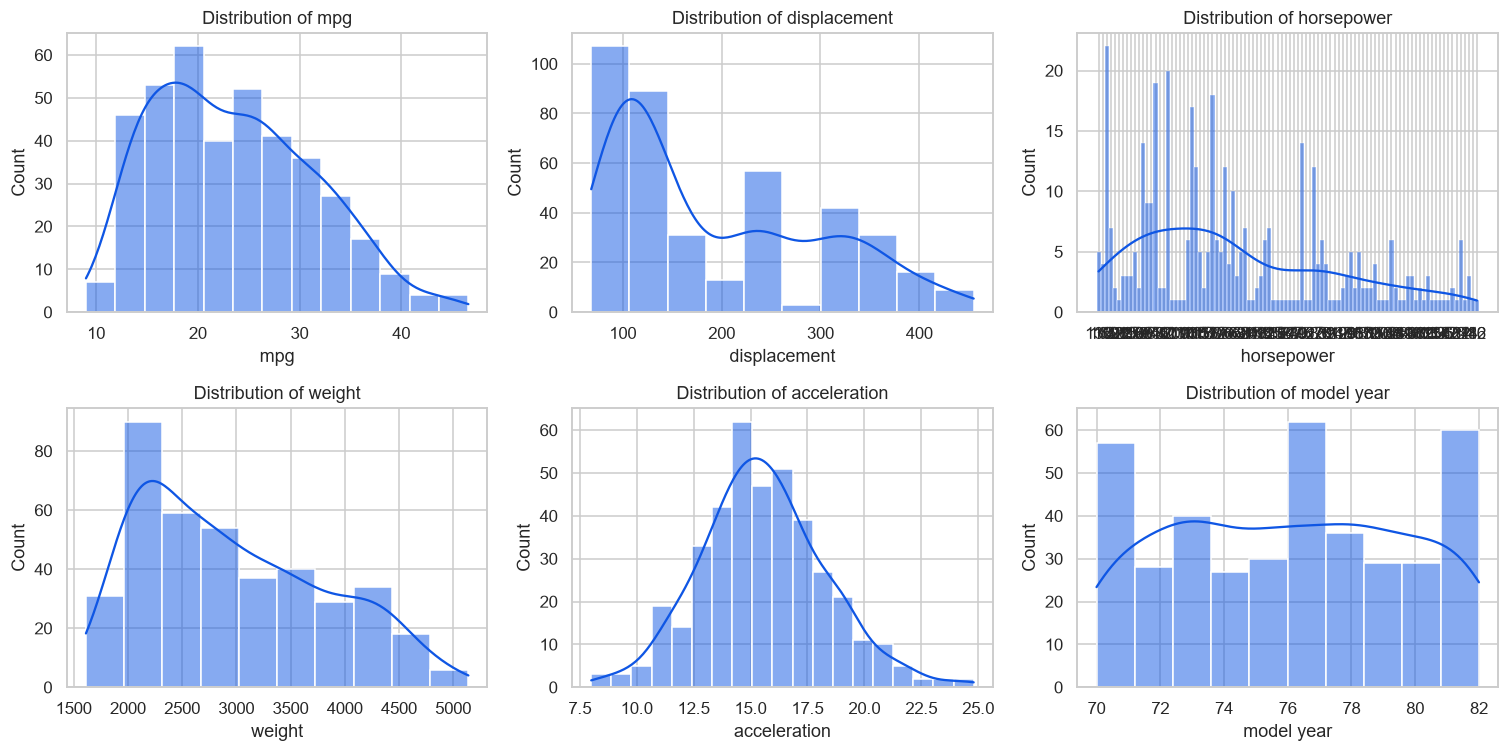

In [144]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.histplot(df_clean[c], ax=axes[i], kde=True, color='#0f56e4')
    axes[i].set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

In [145]:
for i,c in enumerate(['displacement', 'horsepower', 'weight', 'acceleration', 'model year']):
    print(i)

0
1
2
3
4


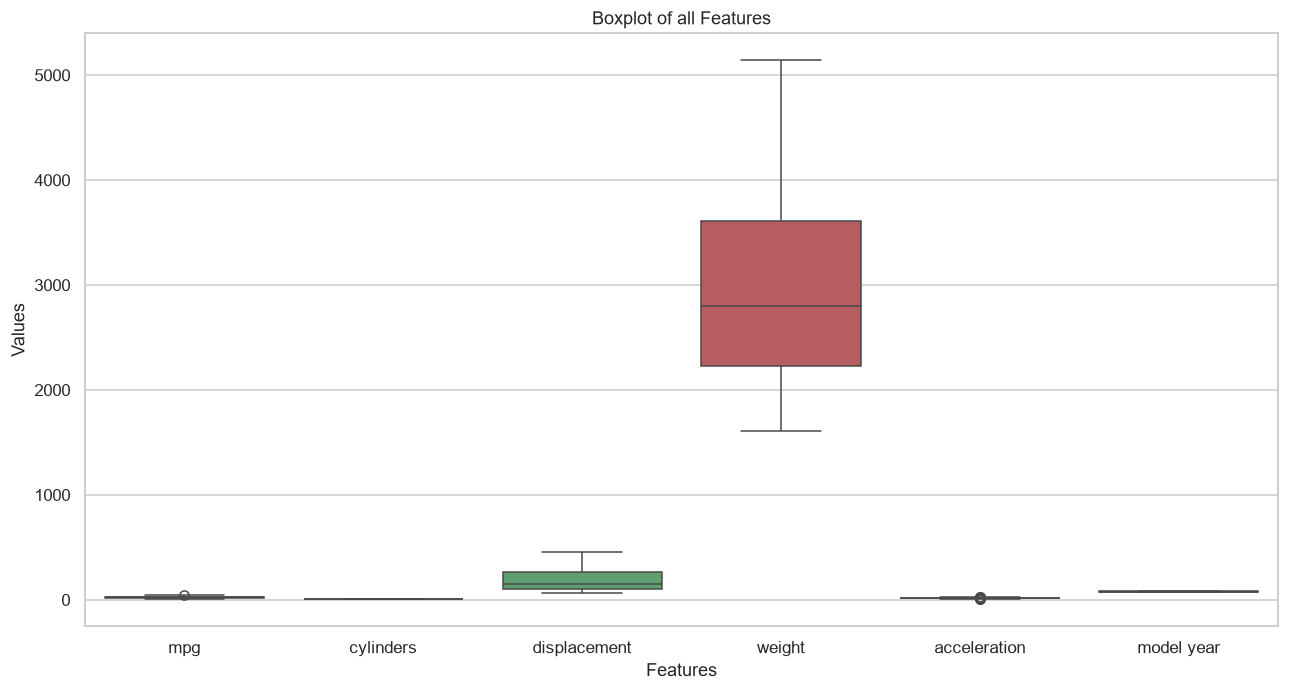

In [146]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df_clean)
plt.title("Boxplot of all Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

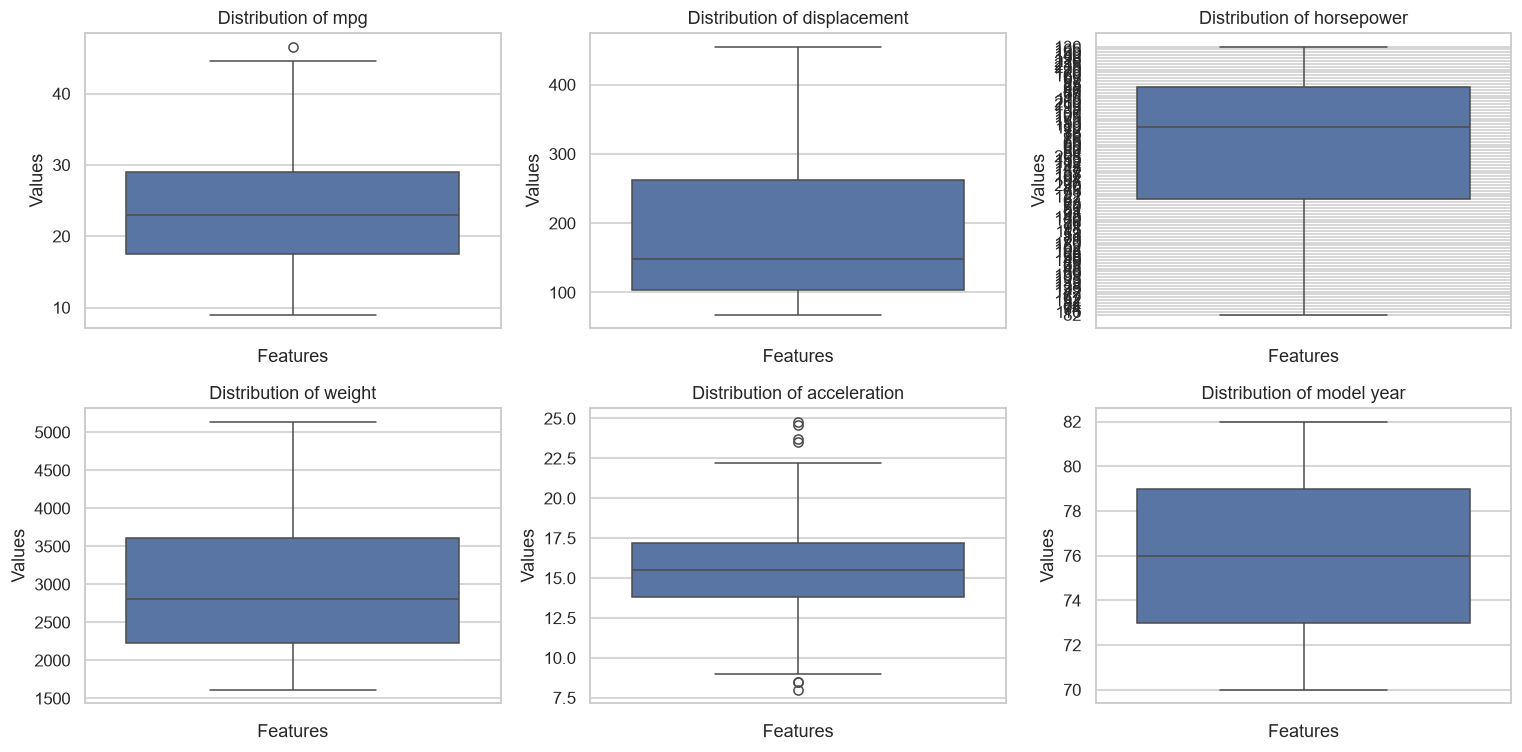

In [147]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.boxplot(data=df_clean[c], ax=axes[i])
    axes[i].set_title(f"Distribution of {c}")
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Values")
plt.tight_layout()
plt.show()

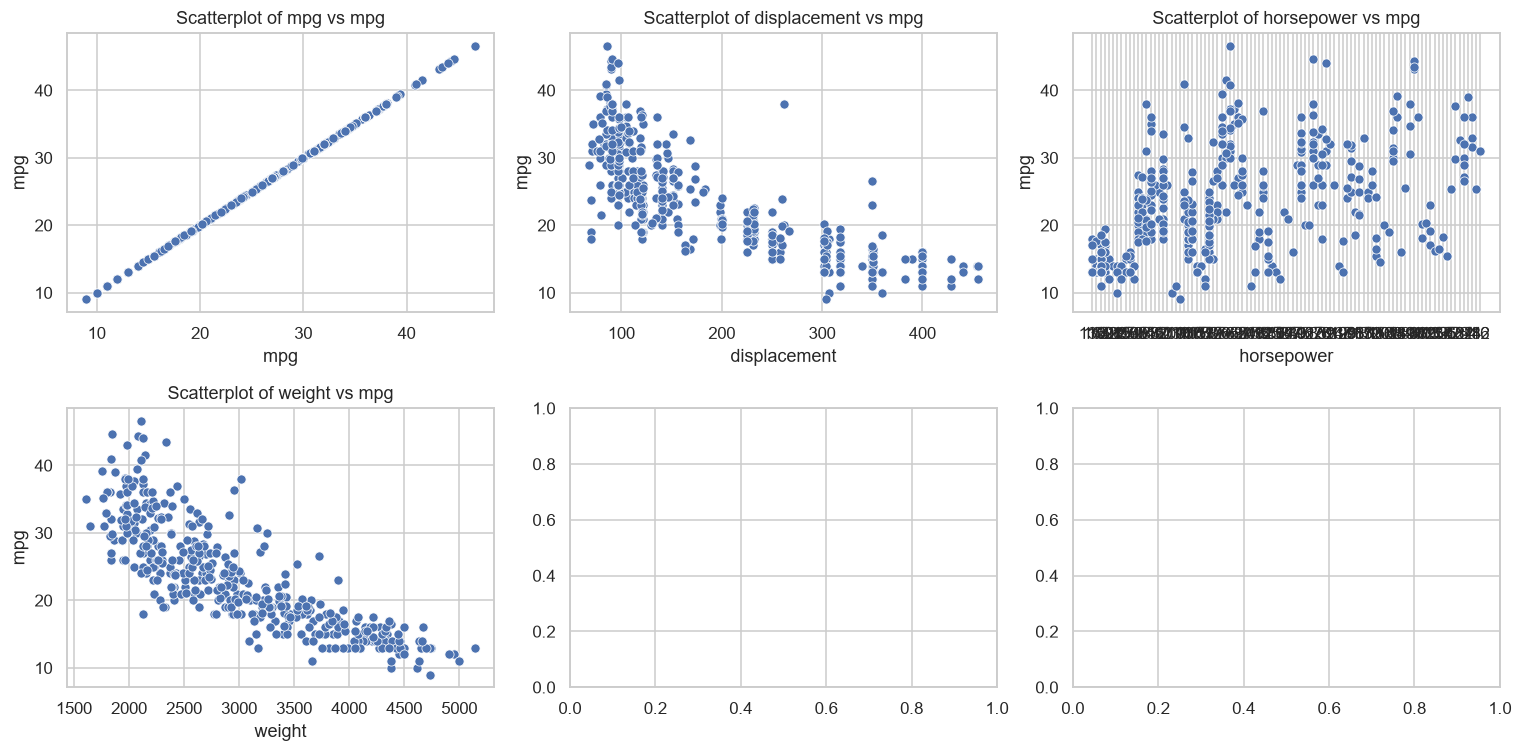

In [148]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols[:4]):
    sns.scatterplot(data=df_clean, x=c, y=TARGET, ax=axes[i])
    axes[i].set_title(f"Scatterplot of {c} vs {TARGET}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

In [149]:
print(df_clean[cols[:4]].dtypes)
print("\nTARGET:")
print(df_clean[TARGET].dtype)

mpg             float64
displacement    float64
horsepower          str
weight            int64
dtype: object

TARGET:
float64


In [150]:
# 'horsepower' Convert it to numeric
df_clean["horsepower"] = pd.to_numeric(
    df_clean["horsepower"],
    errors="coerce"
)

In [151]:
print(df_clean[cols[:4]].dtypes)

mpg             float64
displacement    float64
horsepower      float64
weight            int64
dtype: object


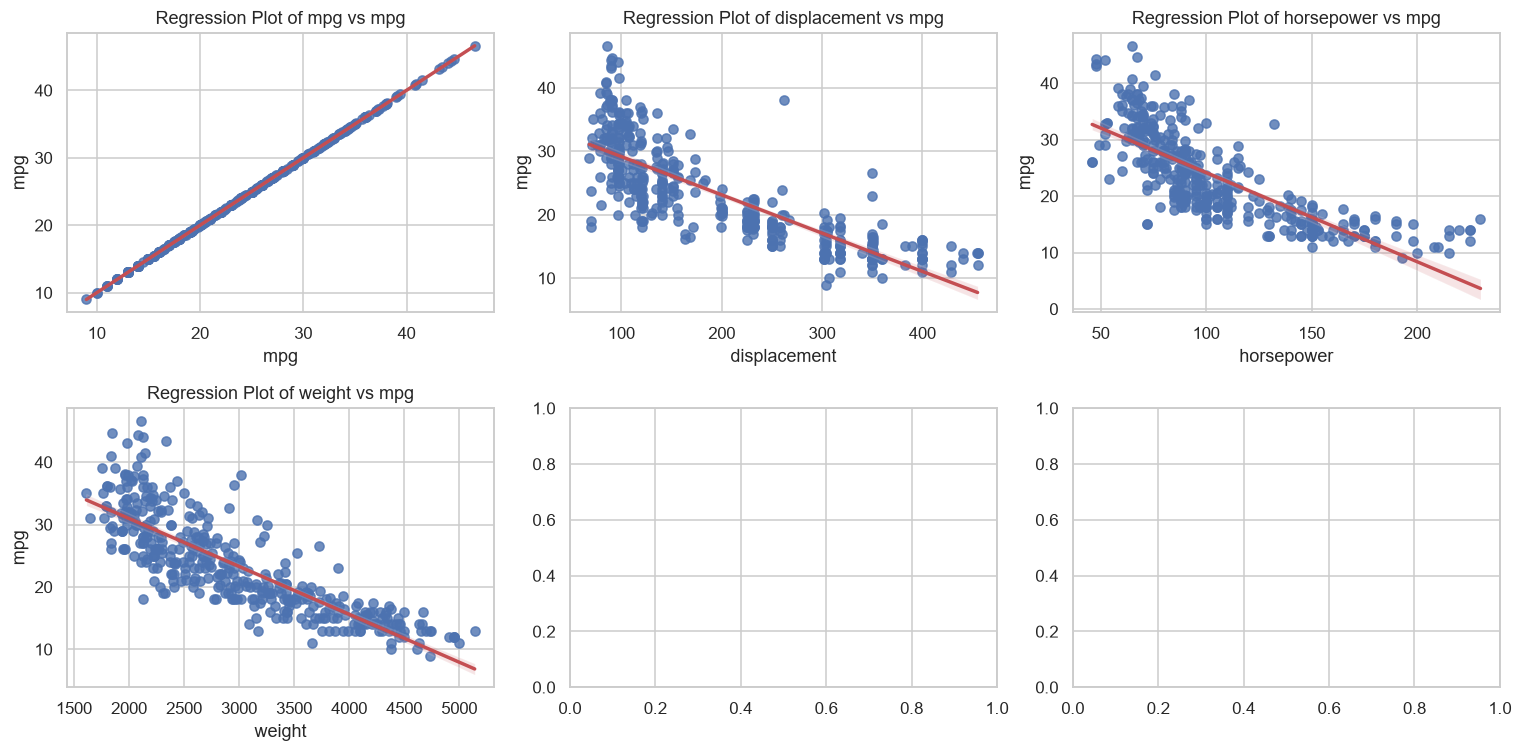

In [152]:
fig, axes = plt.subplots(2,3, figsize=(14, 7))
axes = axes.ravel()
for i, c in enumerate(cols[:4]):
    sns.regplot(data=df_clean, x=c, y=TARGET, ax=axes[i], line_kws=dict(color="r"))
    axes[i].set_title(f"Regression Plot of {c} vs {TARGET}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel(TARGET)
plt.tight_layout()
plt.show()

Correlation Analysis

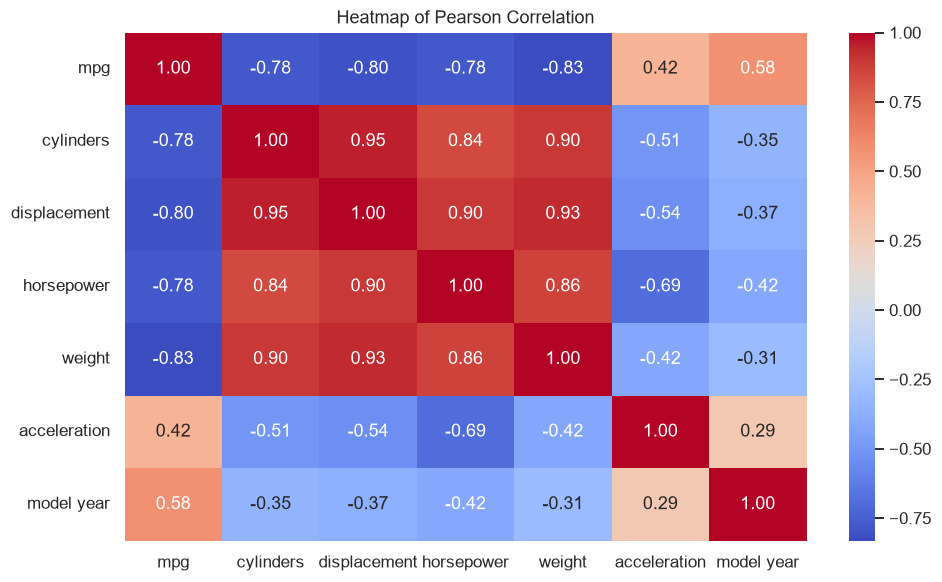

In [153]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap of Pearson Correlation")
plt.show()

In [154]:
df_clean.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


Linear Regression

In [155]:
TARGET = 'mpg' # Y
quan_candidates = ['displacement', 'horsepower', 'weight', 'acceleration', 'model year'] # X

# df_clean[quan_candidates].corrwith(df_clean[TARGET]).sort_values(ascending=False)
df_clean

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82


In [156]:
# Convert horsepower to numeric
df_clean["horsepower"] = pd.to_numeric(
    df_clean["horsepower"],
    errors="coerce"
)

# Remove rows where horsepower could not be converted to a number
df_clean = df_clean.dropna(subset=["horsepower"])

In [157]:
# print all rows where horsepower is NaN
print(df_clean[df_clean["horsepower"].isna()])

Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model year]
Index: []


In [158]:
Y = df_clean[TARGET]
type(Y)

pandas.Series

In [159]:
# Convert Y to numpy array
Y = df_clean[TARGET].values
type(Y)

numpy.ndarray

In [160]:
X = df_clean[quan_candidates].values
X

array([[ 307. ,  130. , 3504. ,   12. ,   70. ],
       [ 350. ,  165. , 3693. ,   11.5,   70. ],
       [ 318. ,  150. , 3436. ,   11. ,   70. ],
       ...,
       [ 135. ,   84. , 2295. ,   11.6,   82. ],
       [ 120. ,   79. , 2625. ,   18.6,   82. ],
       [ 119. ,   82. , 2720. ,   19.4,   82. ]], shape=(392, 5))

In [161]:
# Train: Test = 70:30
# For large datasets, you can use 99:1 split. For small datasets, you can use 60:40 or 50:50 split.

train_size = 0.7
test_size = 1 - train_size

x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=train_size, test_size=test_size, random_state=42)

In [162]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((274, 5), (118, 5), (274,), (118,))

In [166]:
# Train the model
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0. ,-0.01,-0.01, 0.06, 0.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-12.65
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[13964.6 , 653.56, 274.19, 52.76, 28.86]"


In [167]:
model.coef_.tolist()

[-0.001088368113920039,
 -0.009261896919595435,
 -0.006388670050760556,
 0.0649639120567579,
 0.7294560458614198]

In [168]:
model.intercept_

np.float64(-12.645402790663468)

In [171]:
coefficients = pd.DataFrame({
    "Feature": quan_candidates,
    "coefficients": model.coef_.tolist()
    })
coefficients

,Feature,coefficients
0,displacement,-0.001088
1,horsepower,-0.009262
2,weight,-0.006389
3,acceleration,0.064964
4,model year,0.729456


In [172]:
Y__pred = model.predict(x_test)
Y__pred

array([26.31642996, 26.21895873, 33.16321554, 27.24051243, 29.41014589,
       29.29086692,  7.59504563, 29.4345043 , 21.12584116, 29.41619588,
       12.18811   , 23.91132379, 16.27846284, 28.43320659, 22.08399743,
       30.86385601, 21.49321756, 31.70637   , 28.02569018, 29.77253298,
       20.22898171, 34.57304765, 34.06959898, 15.2720119 , 29.09379776,
       26.20126073, 21.17399151, 16.9648988 , 28.97960515, 24.16723572,
       12.8836965 , 23.77584509, 21.47659658, 29.97924639, 11.04080061,
       34.757423  , 11.11776276, 26.55043884, 11.85655317,  7.45918255,
       13.0659818 , 28.08137337, 34.7147151 , 26.75438054, 11.43599908,
        8.59894909, 17.95453832, 31.59061475, 25.71325994, 30.59460444,
       11.68536645, 25.32611697, 24.70302585, 33.36679128, 28.72324903,
       18.00043776, 21.05894612, 23.30794762, 23.38722702, 24.81864856,
        7.11005187, 23.14150232, 27.31684433, 23.33123871, 28.12040797,
       28.83183494, 26.90801203, 29.85215561, 22.45945033,  9.03

In [174]:
# Y_test, Y_pred
eval = rmse(y_test, Y__pred), mean_absolute_error(y_test, Y__pred), r2_score(y_test, Y__pred)
eval

(np.float64(3.1981171837758287), 2.550338797766785, 0.8066725937555248)

In [175]:
mse = mean_squared_error(y_test, Y__pred)
mse

10.227953521162236